In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tejashvi14/medical-insurance-premium-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medical-insurance-premium-prediction' dataset.
Path to dataset files: /kaggle/input/medical-insurance-premium-prediction


In [38]:
import os
df = pd.read_csv(os.path.join(path,"Medicalpremium.csv"))
df

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000
...,...,...,...,...,...,...,...,...,...,...,...
981,18,0,0,0,0,169,67,0,0,0,15000
982,64,1,1,0,0,153,70,0,0,3,28000
983,56,0,1,0,0,155,71,0,0,1,29000
984,47,1,1,0,0,158,73,1,0,1,39000


In [39]:
df = pd.read_csv("/content/drive/MyDrive/Practical/data/Medicalpremiumprediction.csv")
df

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000
...,...,...,...,...,...,...,...,...,...,...,...
4981,45,0,1,0,0,174,54,0,0,0,25000
4982,22,1,1,0,0,166,124,0,0,0,16000
4983,41,0,0,1,0,163,86,0,0,0,38000
4984,59,0,1,0,0,159,60,0,0,2,28000


In [40]:
df.shape

(4986, 11)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4986 entries, 0 to 4985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      4986 non-null   int64
 1   Diabetes                 4986 non-null   int64
 2   BloodPressureProblems    4986 non-null   int64
 3   AnyTransplants           4986 non-null   int64
 4   AnyChronicDiseases       4986 non-null   int64
 5   Height                   4986 non-null   int64
 6   Weight                   4986 non-null   int64
 7   KnownAllergies           4986 non-null   int64
 8   HistoryOfCancerInFamily  4986 non-null   int64
 9   NumberOfMajorSurgeries   4986 non-null   int64
 10  PremiumPrice             4986 non-null   int64
dtypes: int64(11)
memory usage: 428.6 KB


In [42]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000,4986.000000
mean,41.721019,0.419775,0.467108,0.053951,0.178500,168.186522,76.422182,0.206578,0.122343,0.664661,24309.466506
std,14.214230,0.493572,0.498967,0.225944,0.382971,10.207207,14.140521,0.404891,0.327714,0.746145,6290.230491
min,18.000000,0.000000,0.000000,0.000000,0.000000,144.000000,50.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,74.000000,0.000000,0.000000,1.000000,24000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,86.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


In [43]:
df.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


In [44]:
df.duplicated().sum()

np.int64(818)

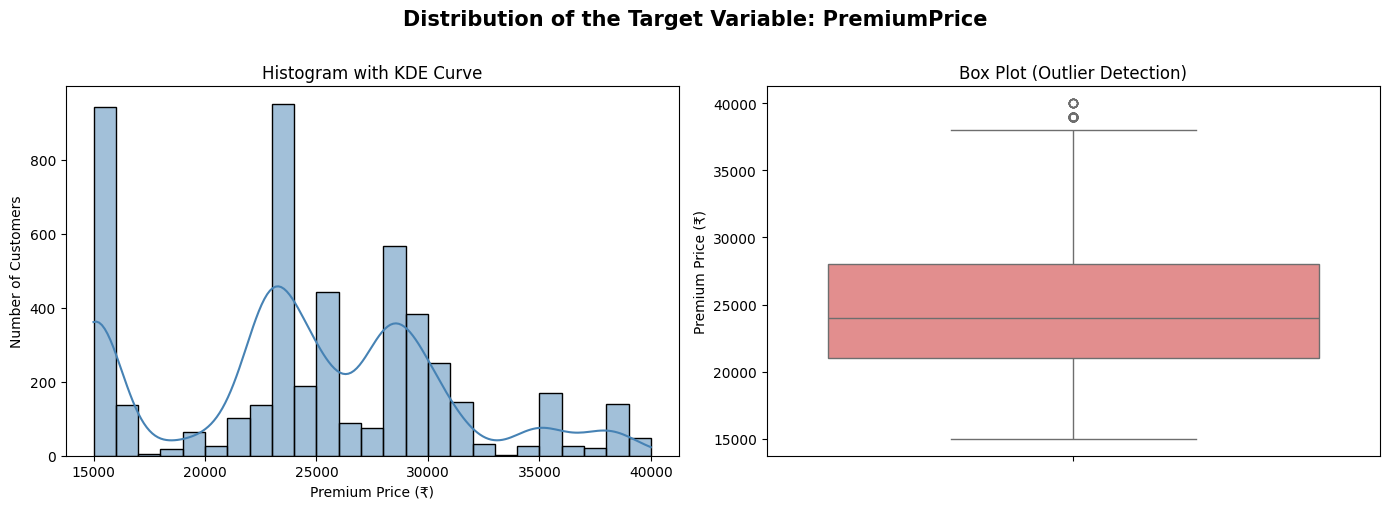

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of the Target Variable: PremiumPrice', fontsize=15, fontweight='bold', y=1.01)

# histogram for premium price
sns.histplot(df['PremiumPrice'], kde=True, color='steelblue', ax=axes[0], bins=25)
axes[0].set_title('Histogram with KDE Curve')
axes[0].set_xlabel('Premium Price (₹)')
axes[0].set_ylabel('Number of Customers')


# boxplot for premium price
sns.boxplot(y=df['PremiumPrice'], color='lightcoral', ax=axes[1])
axes[1].set_title('Box Plot (Outlier Detection)')
axes[1].set_ylabel('Premium Price (₹)')

plt.tight_layout()
plt.show()

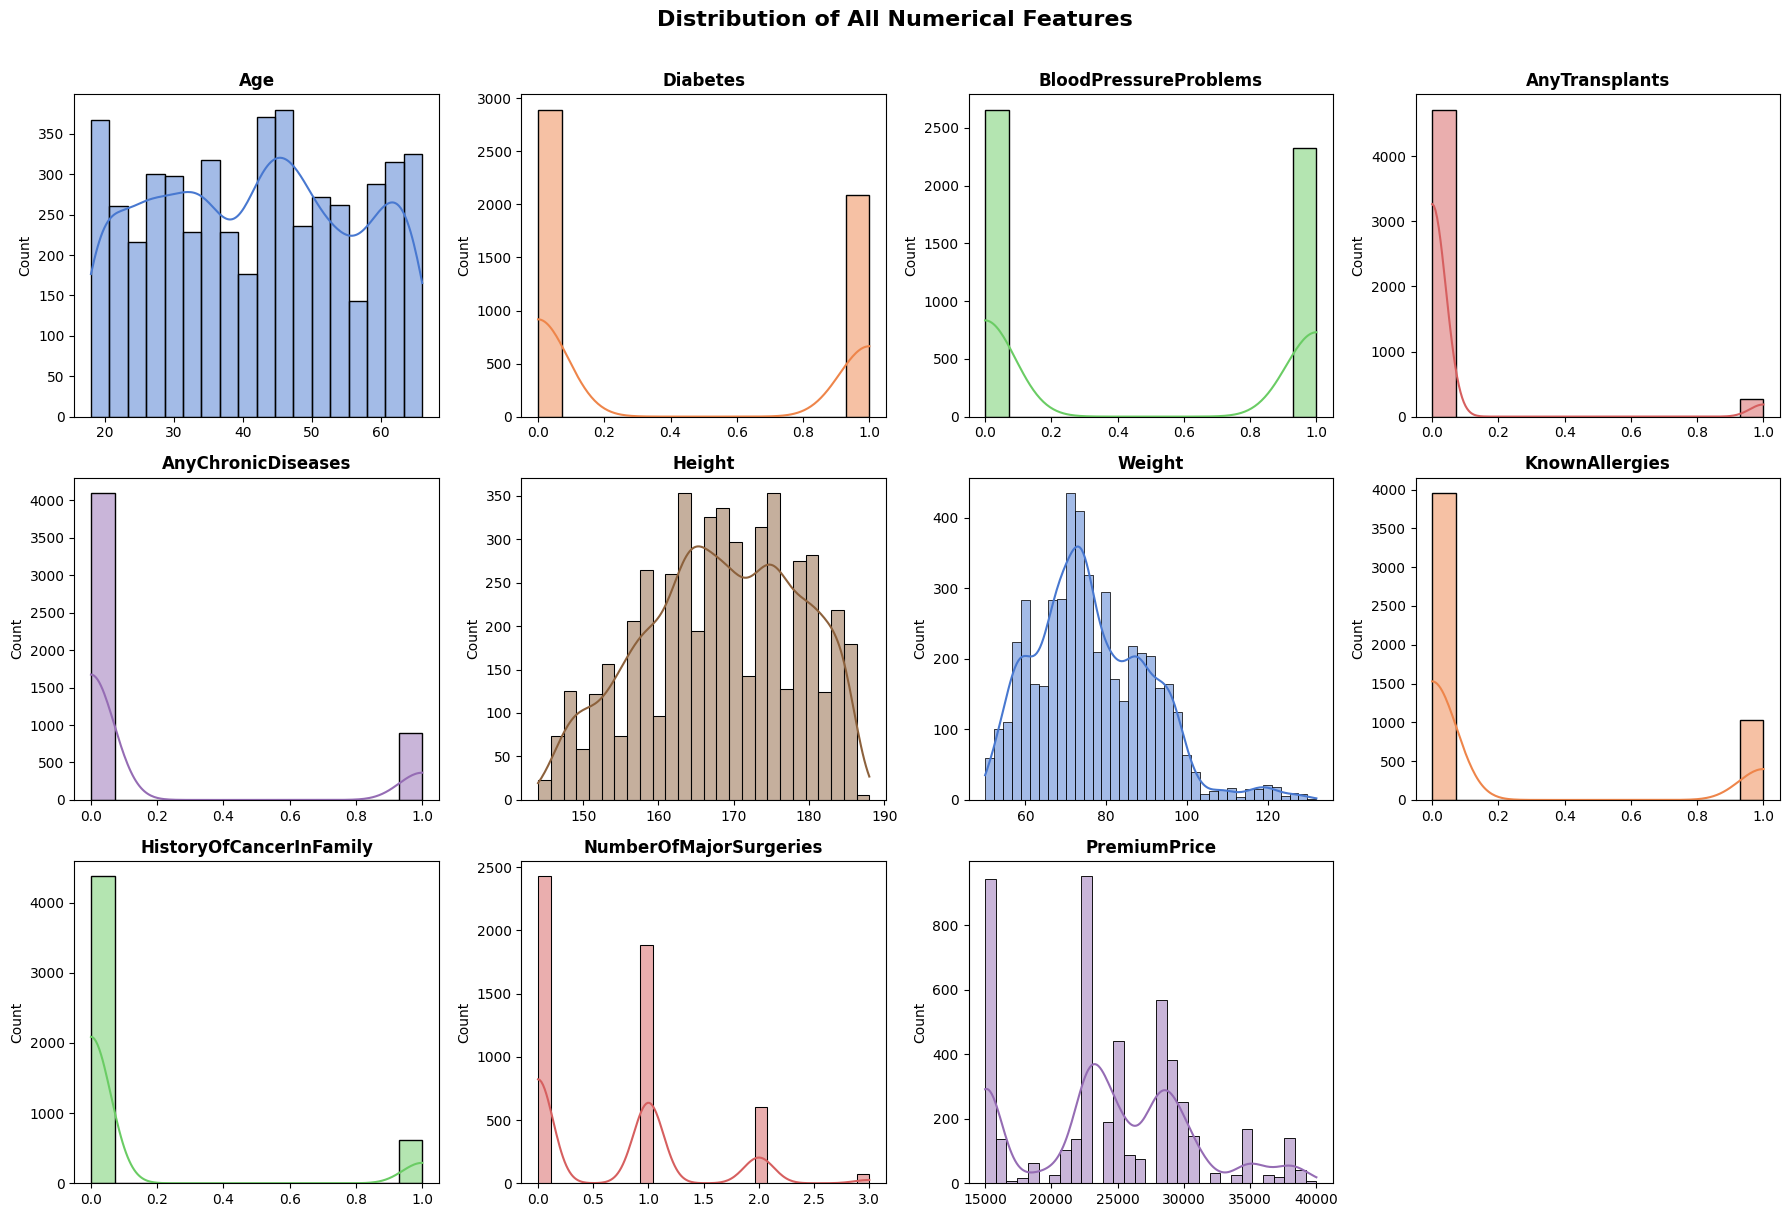

In [46]:
# histplot for numeric values
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols  = 4
n_rows  = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Distribution of All Numerical Features', fontsize=16, fontweight='bold', y=1.01)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

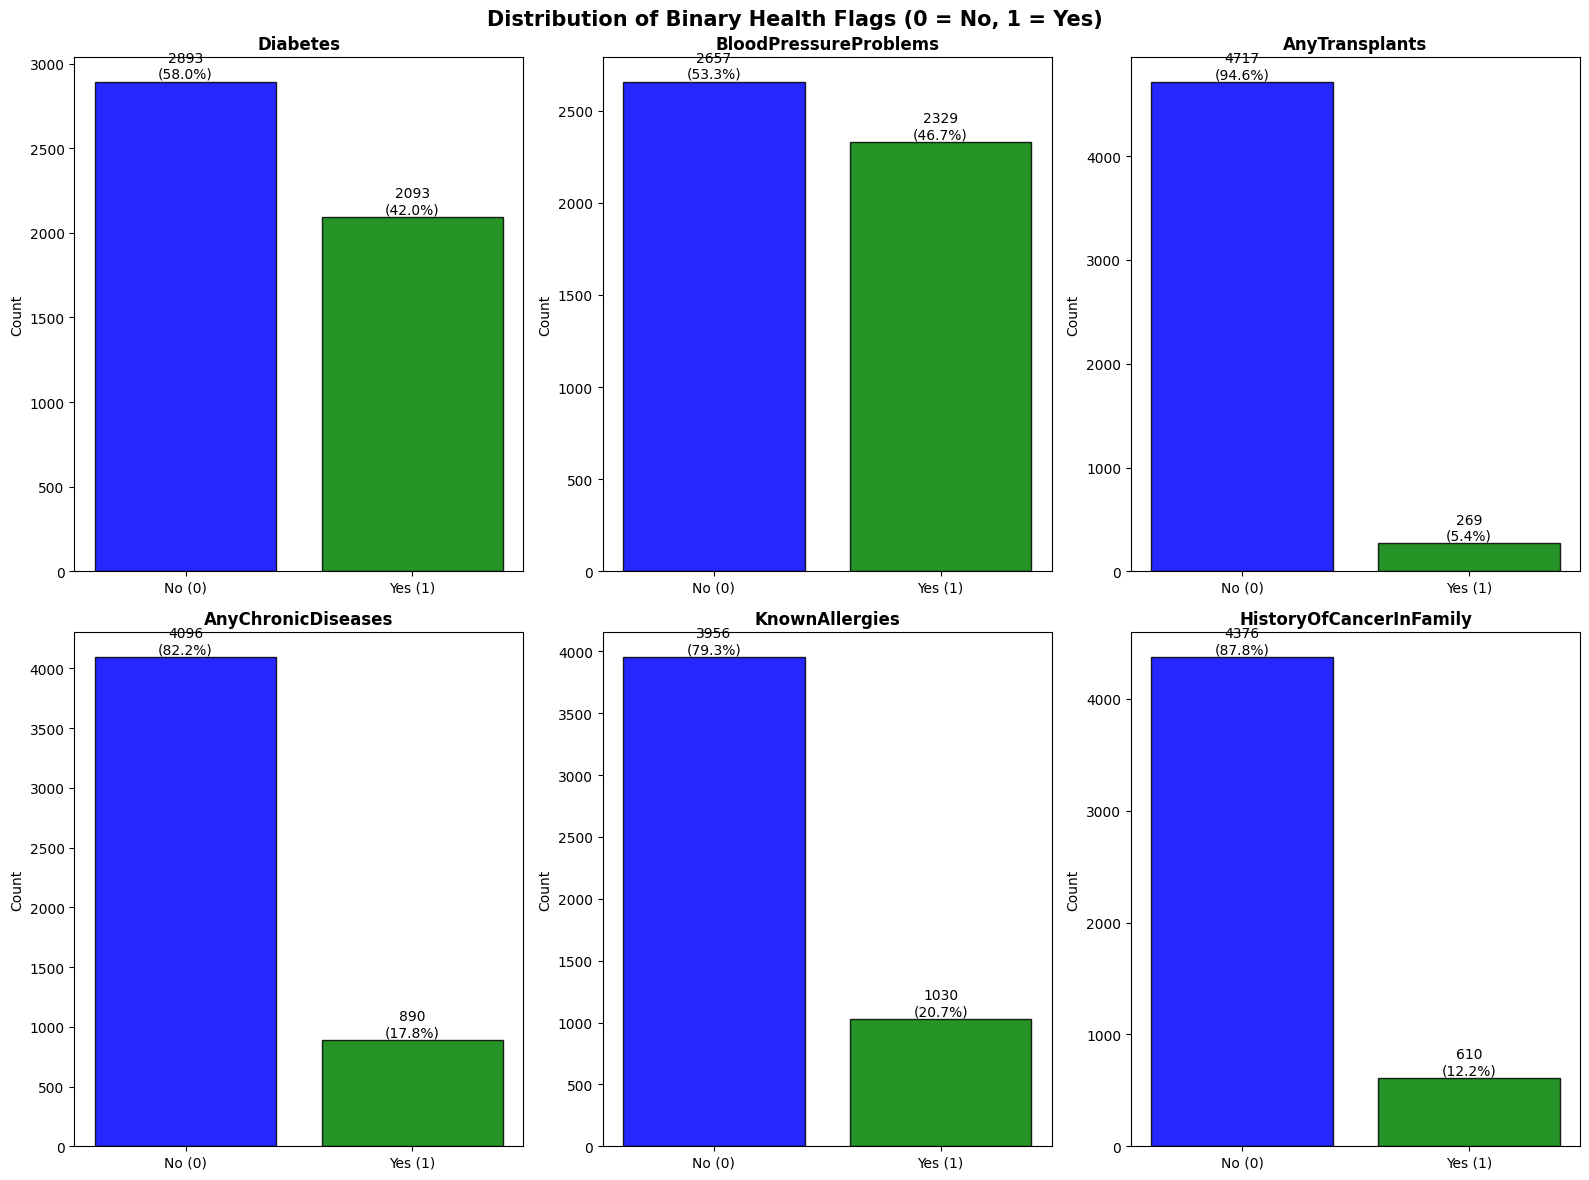

In [47]:
binary_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants',
               'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily']

fig, axes = plt.subplots(2, 3, figsize=(16,12))
fig.suptitle('Distribution of Binary Health Flags (0 = No, 1 = Yes)', fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = ['blue', 'green']

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts().sort_index()

    axes[i].bar(['No (0)', 'Yes (1)'], counts.values, color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')

    for j, v in enumerate(counts.values):
        pct = v / len(df) * 100
        axes[i].text(j, v + 5, f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3299/3775248807.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3299/3775248807.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3299/3775248807.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3299/3775248807.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3299/3775248807.py:10: FutureWarning: 

P

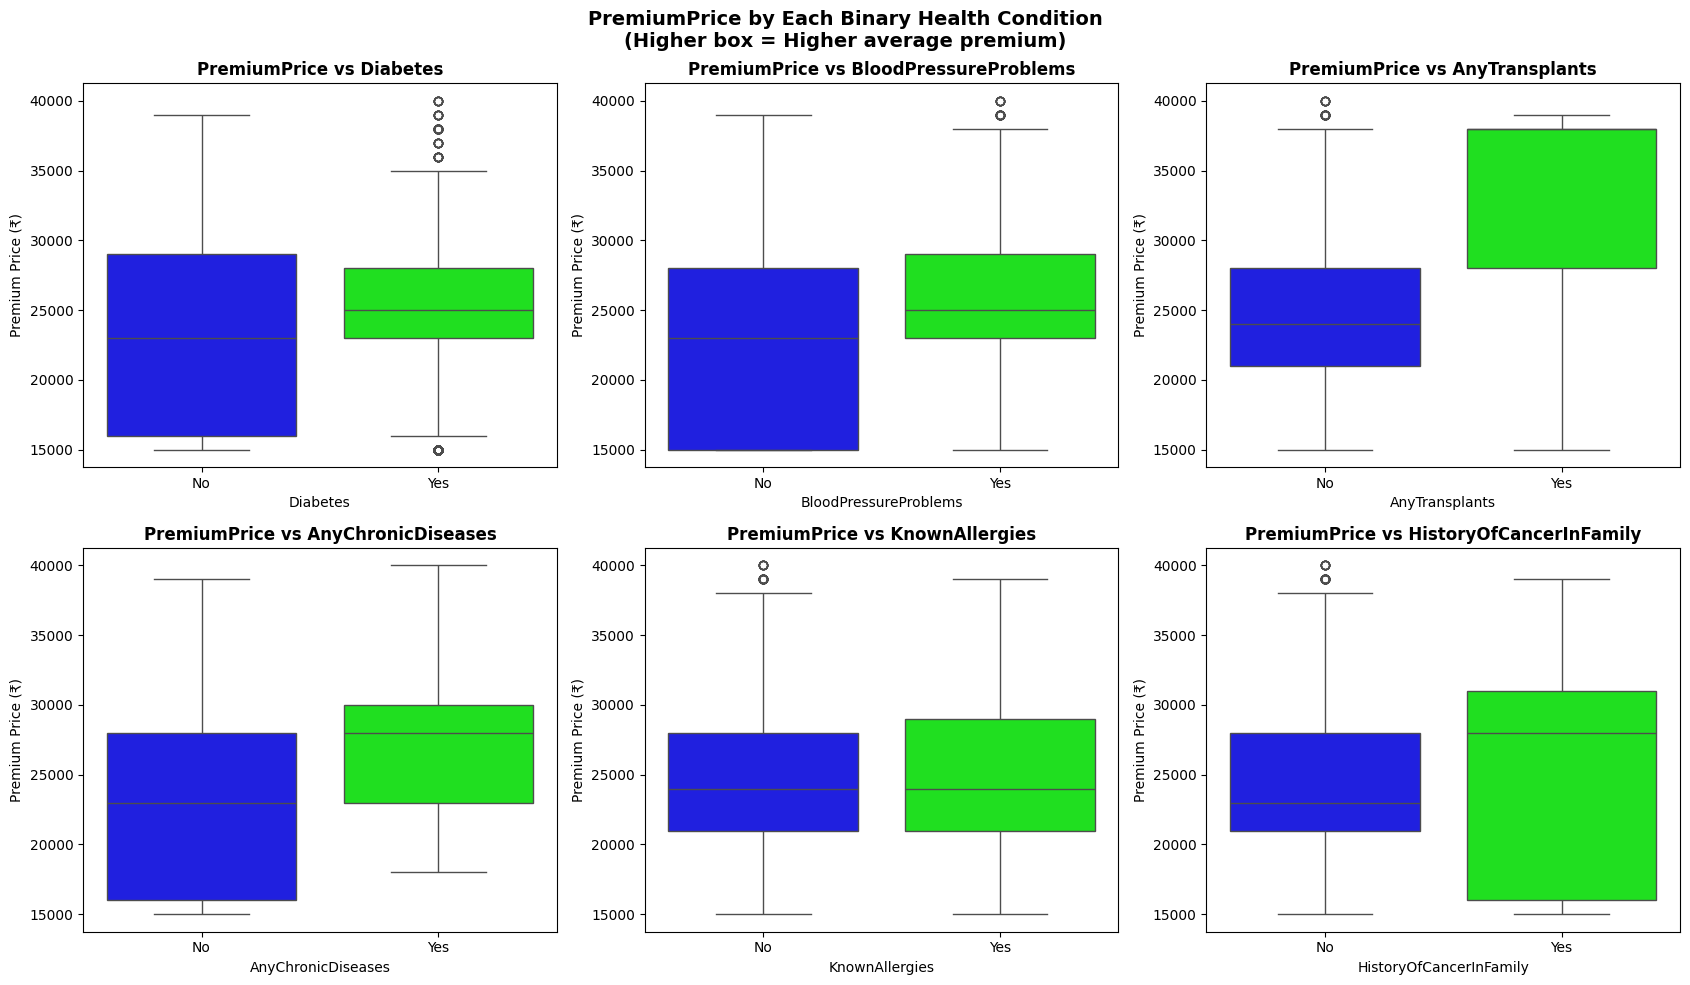

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('PremiumPrice by Each Binary Health Condition\n(Higher box = Higher average premium)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    temp = df.copy()
    temp[col] = temp[col].map({0: 'No', 1: 'Yes'})

    sns.boxplot(
        data=temp, x=col, y='PremiumPrice',
        palette={'No': 'blue', 'Yes': 'lime'},
        order=['No', 'Yes'],
        ax=axes[i]
    )
    axes[i].set_title(f'PremiumPrice vs {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Premium Price (₹)')

plt.tight_layout()
plt.show()

<Axes: >

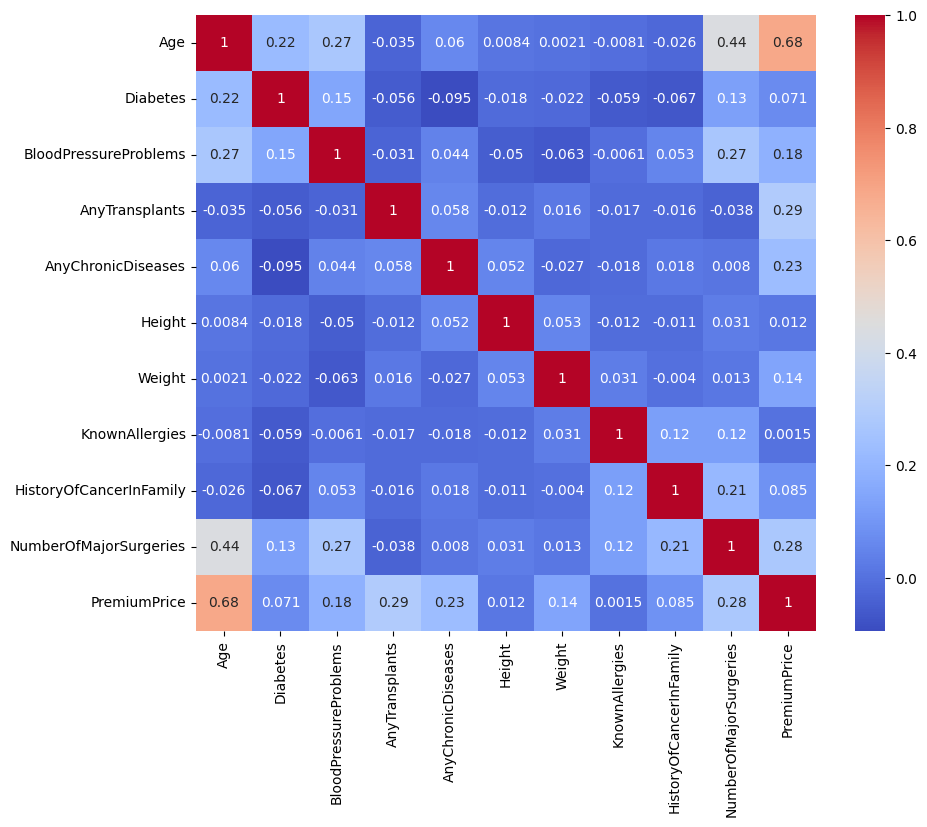

In [49]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True,cmap='coolwarm')

In [50]:
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df['BMI'] = df['BMI'].round(2)

In [51]:
risk_flags = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases','NumberOfMajorSurgeries']
df['HealthRiskScore'] = df[risk_flags].sum(axis=1)

In [52]:
#df['AgeXBMI'] = df['Age'] * df['BMI']

In [53]:

df

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,HealthRiskScore
0,45,0,0,0,0,155,57,0,0,0,25000,23.73,0
1,60,1,0,0,0,180,73,0,0,0,29000,22.53,1
2,36,1,1,0,0,158,59,0,0,1,23000,23.63,3
3,52,1,1,0,1,183,93,0,0,2,28000,27.77,5
4,38,0,0,0,1,166,88,0,0,1,23000,31.93,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4981,45,0,1,0,0,174,54,0,0,0,25000,17.84,1
4982,22,1,1,0,0,166,124,0,0,0,16000,45.00,2
4983,41,0,0,1,0,163,86,0,0,0,38000,32.37,1
4984,59,0,1,0,0,159,60,0,0,2,28000,23.73,3


/tmp/ipykernel_3299/4130030876.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Premium Price (₹)')

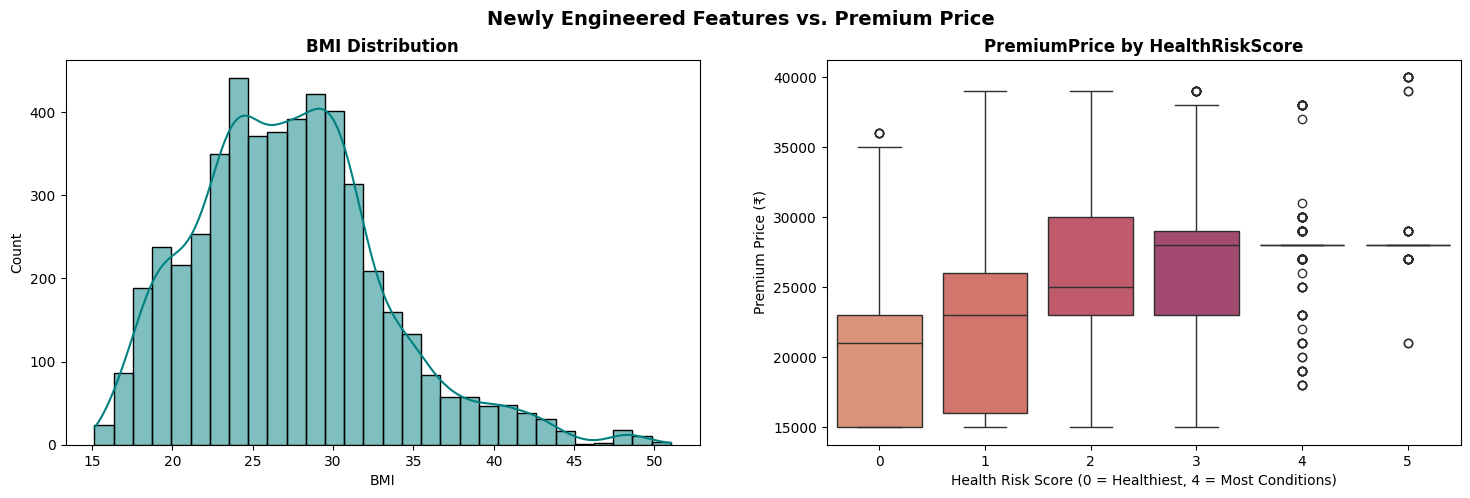

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Newly Engineered Features vs. Premium Price', fontsize=14, fontweight='bold')

sns.histplot(df['BMI'], kde=True, color='teal', ax=axes[0], bins=30)
axes[0].set_title('BMI Distribution', fontweight='bold')
axes[0].set_xlabel('BMI')

sns.boxplot(
    data=df, x='HealthRiskScore', y='PremiumPrice',
    palette='flare', ax=axes[1]
)
axes[1].set_title('PremiumPrice by HealthRiskScore', fontweight='bold')
axes[1].set_xlabel('Health Risk Score (0 = Healthiest, 4 = Most Conditions)')
axes[1].set_ylabel('Premium Price (₹)')


Correlations with PremiumPrice (sorted):
Age                        0.684099
HealthRiskScore            0.387602
AnyTransplants             0.290302
NumberOfMajorSurgeries     0.276168
AnyChronicDiseases         0.228881
BloodPressureProblems      0.184153
Weight                     0.142155
BMI                        0.109324
HistoryOfCancerInFamily    0.084587
Diabetes                   0.070963
Height                     0.012467
KnownAllergies             0.001516


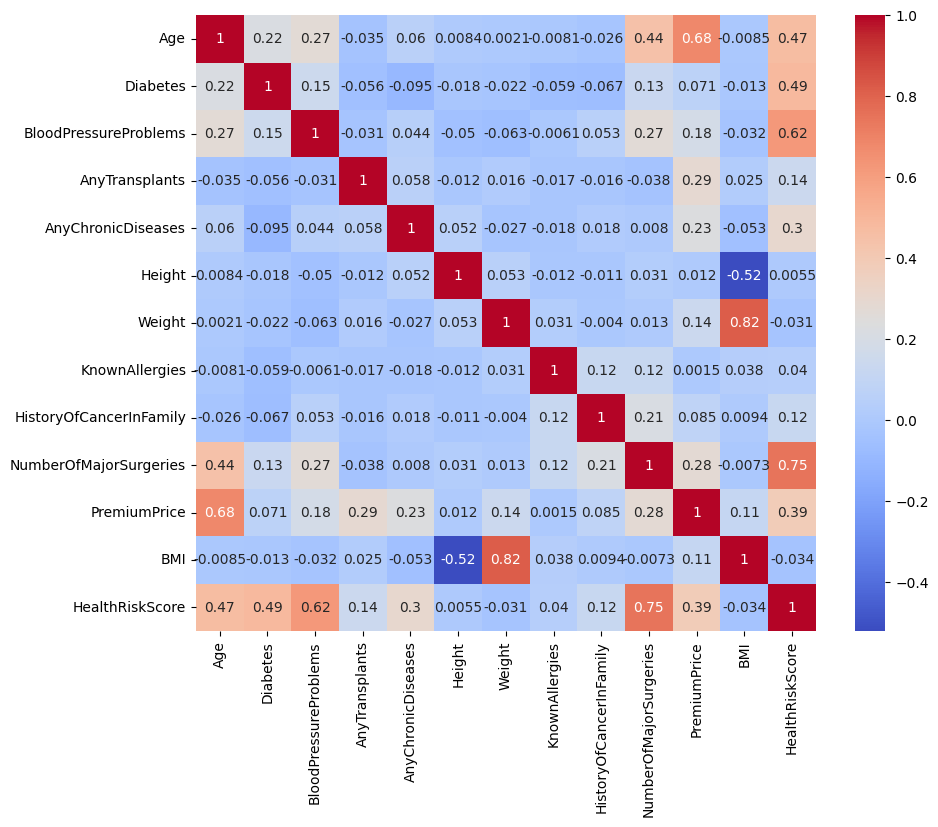

In [55]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr,annot = True,cmap='coolwarm')

print('\nCorrelations with PremiumPrice (sorted):')
target_corr = corr['PremiumPrice'].drop('PremiumPrice').sort_values(ascending=False)
print(target_corr.to_string())

In [57]:
X = df[['Age','HealthRiskScore','AnyTransplants','NumberOfMajorSurgeries','AnyChronicDiseases','BloodPressureProblems','Weight','BMI','HistoryOfCancerInFamily']]
y = df['PremiumPrice']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [59]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Linear SVM": SVR(kernel='linear', C=100, epsilon=0.1),
    "RBF SVM": SVR(kernel='rbf', C=100, gamma=0.1),
    "Polynomial SVM": SVR(kernel='poly', C=100, degree=2),
    "Sigmoid SVM": SVR(kernel='sigmoid', C=100, gamma='scale')
}

In [61]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)

    results.append([name,mse,r2])

In [62]:
result_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(result_df)

                      Model           MSE        R2
0         Linear Regression  1.361543e+07  0.646179
1          Ridge Regression  1.361563e+07  0.646174
2          Lasso Regression  1.361526e+07  0.646183
3  Decision Tree Regression  2.155909e+06  0.943975
4  Random Forest Regression  1.521667e+06  0.960457
5       K-Nearest Neighbors  3.782685e+06  0.901700
6                Linear SVM  1.390130e+07  0.638750
7                   RBF SVM  1.505766e+07  0.608700
8            Polynomial SVM  2.975217e+07  0.226837
9               Sigmoid SVM  1.687256e+07  0.561537


##Using Ensemble Learning

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

In [64]:
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ('lr',models['Linear Regression']),
        ('ridge',models['Ridge Regression']),
        ('lasso',models['Lasso Regression']),
        ('dt',models['Decision Tree Regression']),
        ('knn',models['K-Nearest Neighbors'])
    ],
    final_estimator=models['Random Forest Regression']
)
stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('ridge', Ridge(alpha=1)),
                              ('lasso', Lasso(alpha=0.1)),
                              ('dt', DecisionTreeRegressor()),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=RandomForestRegressor(n_estimators=150))

In [65]:
y_pred = stack_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Stacking',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 2473849.0636779144
R2: 0.9357126720228198


In [66]:
from sklearn.ensemble import VotingRegressor

vote_model = VotingRegressor(
    estimators=[
        ('lr',models['Linear Regression']),
        ('ridge',models['Ridge Regression']),
        ('lasso',models['Lasso Regression']),
        ('dt',models['Decision Tree Regression']),
        ('knn',models['K-Nearest Neighbors']),
        ('rf',models['Random Forest Regression'])
    ]
)

vote_model.fit(X_train,y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('ridge', Ridge(alpha=1)),
                            ('lasso', Lasso(alpha=0.1)),
                            ('dt', DecisionTreeRegressor()),
                            ('knn', KNeighborsRegressor()),
                            ('rf', RandomForestRegressor(n_estimators=150))])

In [67]:
y_pred = vote_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Voting',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 4653285.145644224
R2: 0.8790761842662206


In [68]:
results_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(results_df)

                       Model           MSE        R2
0          Linear Regression  1.361543e+07  0.646179
1           Ridge Regression  1.361563e+07  0.646174
2           Lasso Regression  1.361526e+07  0.646183
3   Decision Tree Regression  2.155909e+06  0.943975
4   Random Forest Regression  1.521667e+06  0.960457
5        K-Nearest Neighbors  3.782685e+06  0.901700
6                 Linear SVM  1.390130e+07  0.638750
7                    RBF SVM  1.505766e+07  0.608700
8             Polynomial SVM  2.975217e+07  0.226837
9                Sigmoid SVM  1.687256e+07  0.561537
10                  Stacking  2.473849e+06  0.935713
11                    Voting  4.653285e+06  0.879076


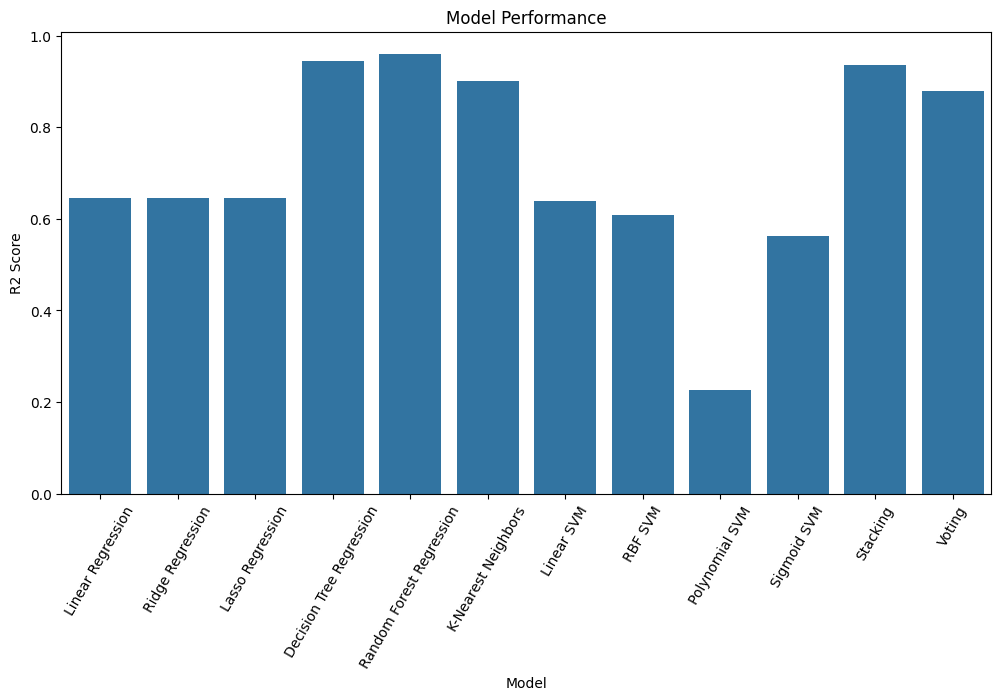

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2', data=results_df)
plt.title('Model Performance')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=60)
plt.show()

In [70]:
best_model = RandomForestRegressor(n_estimators=150)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 1538139.01120087
R2: 0.9600287468870251


In [71]:
import pickle
pickle.dump(best_model,open("RandomForest_model1.pkl","wb"))
pickle.dump(scaler,open("RandomForest_scaler1.pkl","wb"))